# Bayes Ingenuo (Gaussiano) : (Gaussian) Naive Bayes
Arlen Almansa

### El método de Bayes Ingenuo es válido para problemas de clasificación y hace diferencia sobre si los datos de entrada son categóricos o numéricos.

El caso de métodos de Bayes para regresión genera otra cantidad de modelos que no veremos por el momento.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from collections import Counter 

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score  
from sklearn.metrics import confusion_matrix

from sklearn.naive_bayes import GaussianNB


In [4]:
mypath = "pima_indians_diabetes.csv"
data = pd.read_csv(mypath, sep=",", header="infer")
data.head(3)

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0


In [9]:
columnas = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age',
'Outcome']

data = pd.read_csv(
    "pima_indians_diabetes.csv",
    names=columnas)
data.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [11]:
X = data[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]
Y = data[['Outcome']]

In [12]:
Counter(Y['Outcome'])


Counter({0: 500, 1: 268})

### Interpretación de la distribución de clases
El resultado `Counter({0: 500, 1: 268})` muestra la cantidad de registros pertenecientes a cada clase de la variable objetivo **Outcome**.
- **Clase 0:** 500 registros.
- **Clase 1:** 268 registros.
- **Total:** 768 registros.
Esto significa que aproximadamente el **65.1%** de los registros pertenecen a la clase 0 y el **34.9%** a la clase 1.
Por lo tanto, existe un **desbalance entre las clases**, ya que la clase 0 tiene casi el doble de observaciones que la clase 1. Este aspecto debe considerarse al entrenar y evaluar el modelo de clasificación.

In [13]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, Y, train_size=0.7, random_state=7)

print(Xtrain.shape)
print(Xtest.shape)
print(ytrain.shape)
print(ytest.shape)


(537, 8)
(231, 8)
(537, 1)
(231, 1)


### Interpretación de la división de los datos
Los resultados muestran las dimensiones de los conjuntos utilizados para el entrenamiento y prueba del modelo:
- **X_train (537, 8):** contiene 537 registros y 8 variables predictoras para entrenar el modelo.
- **X_test (231, 8):** contiene 231 registros y 8 variables predictoras para evaluar el modelo.
- **Y_train (537, 1):** contiene las clases correspondientes a los 537 registros de entrenamiento.
- **Y_test (231, 1):** contiene las clases reales de los 231 registros de prueba.

En total se tienen **768 registros**, de los cuales aproximadamente el **70% se utiliza para entrenamiento y el 30% para prueba**.
Esta división permite entrenar el modelo con una parte de los datos y posteriormente evaluar su capacidad de clasificación utilizando datos que no fueron empleados durante el entrenamiento.

In [14]:
kfold = KFold(n_splits=10, random_state=7, shuffle=True)
modeloGNB = GaussianNB()
sol = cross_val_score(modeloGNB, Xtrain, np.ravel(ytrain), cv=kfold)
print(sol.mean())


0.7614954577218728


### Interpretación de la validación cruzada del modelo Gaussian Naive Bayes
Se evaluó el modelo **Gaussian Naive Bayes (GaussianNB)** mediante una validación cruzada **K-Fold de 10 particiones**.
El resultado promedio obtenido fue de **0.7615**, equivalente aproximadamente a un **76.15% de exactitud**.
Esto significa que, durante las diferentes particiones de la validación cruzada, el modelo logró clasificar correctamente en promedio alrededor del **76% de los registros**.
Este resultado permite obtener una estimación más confiable del rendimiento del modelo, ya que su desempeño se evalúa utilizando diferentes grupos de datos para entrenamiento y validación.

In [15]:
modeloGNB.fit(Xtrain, np.ravel(ytrain))
yhat = modeloGNB.predict(Xtest)

cm = confusion_matrix(ytest, np.ravel(yhat))    # los renglones son los reales y las columnas las predicciones.
print(cm)


[[116  31]
 [ 29  55]]


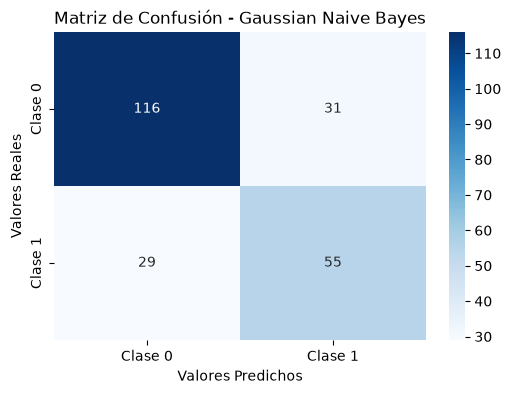

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
# Graficar matriz de confusión
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Clase 0', 'Clase 1'],
    yticklabels=['Clase 0', 'Clase 1'])

plt.title('Matriz de Confusión - Gaussian Naive Bayes')
plt.xlabel('Valores Predichos')
plt.ylabel('Valores Reales')

plt.show()

### Interpretación de la matriz de confusión
La matriz de confusión obtenida con el modelo **Gaussian Naive Bayes** fue:
[[116, 31],
 [29, 55]]
Los resultados indican que:
- **116 verdaderos negativos (VN):** casos de la clase 0 clasificados correctamente.
- **31 falsos positivos (FP):** casos de la clase 0 clasificados incorrectamente como clase 1.
- **29 falsos negativos (FN):** casos de la clase 1 clasificados incorrectamente como clase 0.
- **55 verdaderos positivos (VP):** casos de la clase 1 clasificados correctamente.

En total, el modelo clasificó correctamente **171 de los 231 registros de prueba**, obteniendo una exactitud aproximada del **74.0%**.
La matriz permite observar que el modelo tiene una mayor capacidad para identificar correctamente los casos de la **clase 0** que los de la **clase 1**, ya que existen más aciertos en la clase 0.

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import RocCurveDisplay 


In [19]:
modelokNN = KNeighborsClassifier().fit(Xtrain, np.ravel(ytrain))
modelokNN.score(Xtest,ytest)


0.6883116883116883

### Interpretación del modelo K-Nearest Neighbors (KNN)
Se entrenó un modelo **K-Nearest Neighbors (KNN)** utilizando los datos de entrenamiento y posteriormente se evaluó con los datos de prueba.
El modelo obtuvo un **score de 0.6883**, equivalente aproximadamente a una **exactitud del 68.83%**.
Esto significa que el modelo KNN logró clasificar correctamente cerca del **69% de los registros del conjunto de prueba**.
Al compararlo con el modelo **Gaussian Naive Bayes**, que obtuvo aproximadamente un **74% de exactitud** en los datos de prueba, KNN presenta un rendimiento menor. Por lo tanto, hasta este punto, **Gaussian Naive Bayes muestra un mejor desempeño para este conjunto de datos**.

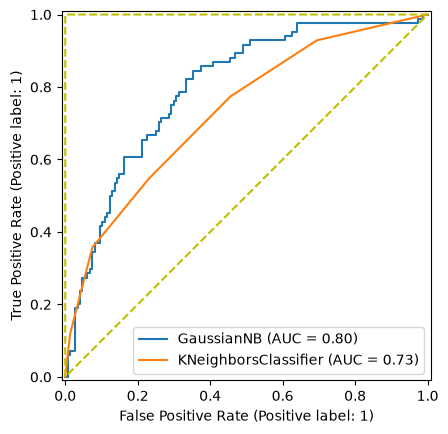

In [20]:
gnb_curve = RocCurveDisplay.from_estimator(modeloGNB, Xtest, ytest)
knn_curve = RocCurveDisplay.from_estimator(modelokNN, Xtest, ytest, ax=gnb_curve.ax_)

plt.plot([0,0,1,0],[0,1,1,0], 'y--')
plt.show() 


### Interpretación de la curva ROC
La curva ROC permite comparar la capacidad de los modelos **Gaussian Naive Bayes** y **K-Nearest Neighbors (KNN)** para distinguir entre las dos clases.

Los resultados del área bajo la curva (AUC) son:
- **Gaussian Naive Bayes: AUC = 0.80**
- **KNN: AUC = 0.73**

Un valor de AUC más cercano a **1** representa una mejor capacidad de clasificación, mientras que un valor cercano a **0.5** indica un desempeño similar a una clasificación aleatoria.
En este caso, **Gaussian Naive Bayes presenta el mejor desempeño**, con un AUC de 0.80, superando al modelo KNN con 0.73. Además, su curva ROC se encuentra generalmente más cerca de la esquina superior izquierda, lo que indica un mejor equilibrio entre la detección de verdaderos positivos y los falsos positivos.
Por lo tanto, según la curva ROC y el AUC, **Gaussian Naive Bayes es el modelo más adecuado de los dos para este conjunto de datos**.